In [1]:
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# I - Chargement et traitement des données de l'API de TMDB

La première étape consiste à charger les données de TMDB grâce à leur API

In [6]:
#ids= td.get_movie_ids_list(20, headers=td.headers)
df=td.get_movies_info([random.randint(100, 10000) for _ in range(50)],headers=td.headers)
df.head(5)

getting movie info


100%|██████████| 50/50 [00:11<00:00,  4.43it/s]


,success,status_code,status_message,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,False,/b4VAgPHGL33OA5QNZCYi0jU5Nma.jpg,None,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",,800.0,...,Released,,The Young and the Damned,False,8.0,481.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,False,/anXAg6TfQamdZ497hEJKXPz7Fqf.jpg,None,0.0,"[{'id': 18, 'name': 'Drama'}]",,6514.0,...,Released,,Die Todesautomatik,False,2.0,1.0,NaN,NaN,NaN,NaN


In [8]:
df_cleaned = df[df['status_message'].isna()]
#df_cleaned = df_cleaned[df_cleaned['revenue']!=0]
#df_cleaned = df_cleaned[df_cleaned['budget']!=0]
df_cleaned.head(4)

,success,status_code,status_message,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
3,NaN,NaN,NaN,False,/b4VAgPHGL33OA5QNZCYi0jU5Nma.jpg,None,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",,800.0,...,Released,,The Young and the Damned,False,8.0,481.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,False,/anXAg6TfQamdZ497hEJKXPz7Fqf.jpg,None,0.0,"[{'id': 18, 'name': 'Drama'}]",,6514.0,...,Released,,Die Todesautomatik,False,2.0,1.0,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,False,/p9hCMDREAEkxlYye7ZNWuxkePba.jpg,None,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",,5286.0,...,Released,The beautiful game just got prettier,Eleven Men Out,False,5.8,16.0,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,False,None,None,0.0,"[{'id': 18, 'name': 'Drama'}]",,6363.0,...,Released,,Die Geierwally,False,4.8,2.0,NaN,NaN,NaN,NaN


Telles quelles les données sont nombreuses et pas toutes nécessaires. Pour la lisibilité on élimine certaines colones, et traite certaines données. Par ailleurs, on construit de variables "overview_count" et "title_count" qui comptent le nombre de caractère de "overview" et de "title".

In [9]:
df1=td.drop_useless_info(df_cleaned)
df1=td.keep_main_genre(df1)
df1=td.full_poster_path(df1)
df1=td.count_words(df1)
df1.head(3)

,success,status_code,status_message,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count
3,NaN,NaN,NaN,0.0,800.0,A group of juvenile delinquents live a violent...,17.501,1950-12-09,0.0,82.0,The Young and the Damned,8.0,481.0,18,Drama,https://image.tmdb.org/t/p/original//cDCvmYoyq...,174,24
4,NaN,NaN,NaN,0.0,6514.0,,1.655,2007-11-26,0.0,90.0,Die Todesautomatik,2.0,1.0,18,Drama,https://image.tmdb.org/t/p/original//x68JbAE2A...,0,18
5,NaN,NaN,NaN,0.0,5286.0,The star player of Icelands top football team ...,2.398,2005-09-02,0.0,87.0,Eleven Men Out,5.8,16.0,18,Drama,https://image.tmdb.org/t/p/original//koeVIanrZ...,433,14


# II - Analyse descriptive des données

# III - Prédiction des notes et du genre d'un film

## B - Prédire le genre grâce à des Forêts Aléatoires

On s'intéresse maintenant au genre d'un film, et on cherche à le prédire gr6ace à nos données. On va utiliser pour cela un modèle classique de Machine Learning: les forêts aléatoires. 

In [10]:
dfrf=df1[df1['main_genre_id'].isin([28,18, 35])]

X=dfrf.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "main_genre_id"])
y=dfrf['main_genre_id']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Création et entraînement du modèle
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 4. Prédictions
y_pred = model.predict(X_test)

# 5. Évaluation
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

          18       0.50      0.50      0.50         2
          35       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [11]:
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance)

vote_count        0.144679
title_count       0.130077
overview_count    0.127915
popularity        0.127727
vote_average      0.127000
revenue           0.123402
budget            0.120759
runtime           0.098440
status_message    0.000000
success           0.000000
status_code       0.000000
dtype: float64



Rapport de classification :
              precision    recall  f1-score   support

      Action       0.00      0.00      0.00         0
   Adventure       0.00      0.00      0.00         0
      Comedy       0.60      1.00      0.75         3
       Crime       0.00      0.00      0.00         0
       Drama       0.00      0.00      0.00         2
      Horror       0.00      0.00      0.00         0
       Music       0.00      0.00      0.00         0
     Mystery       0.00      0.00      0.00         0

    accuracy                           0.60         5
   macro avg       0.07      0.12      0.09         5
weighted avg       0.36      0.60      0.45         5

Précision du modèle : 0.6000


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/me

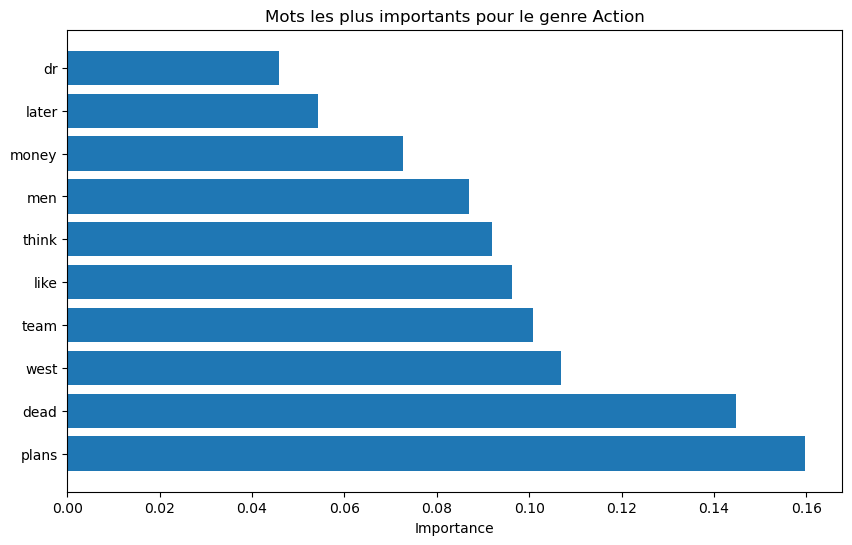

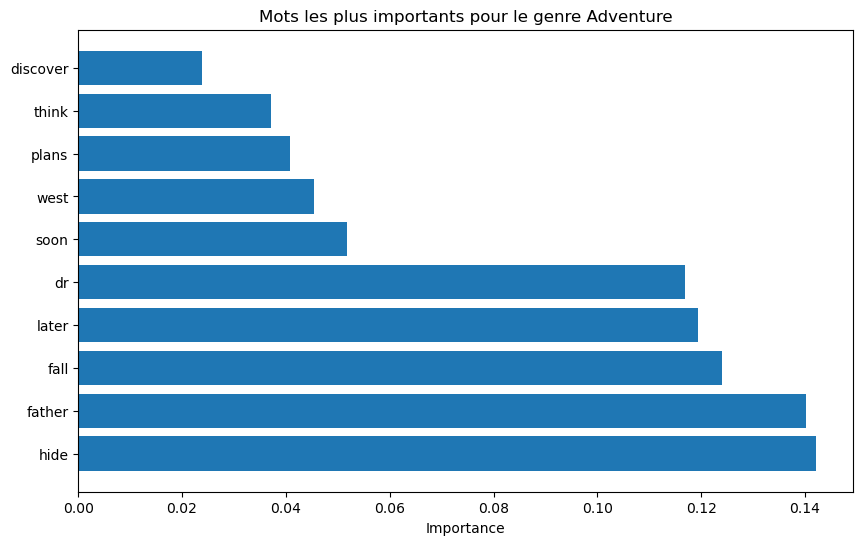

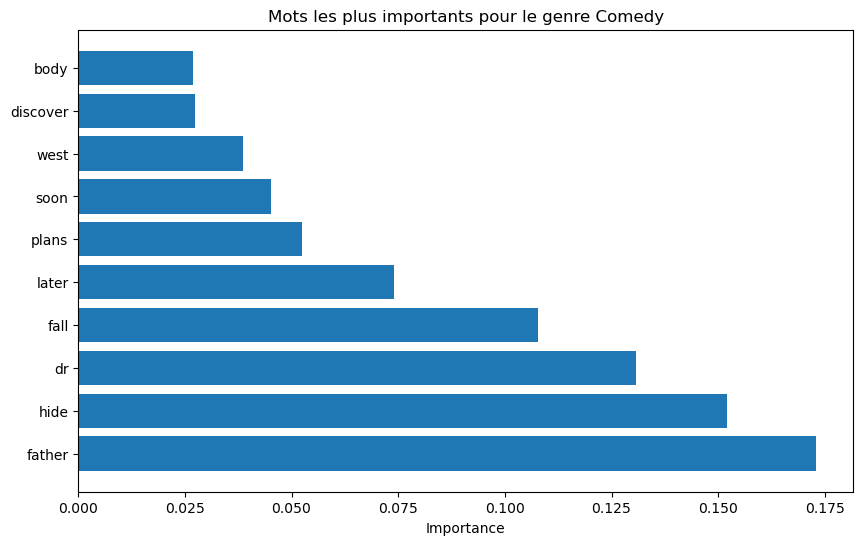

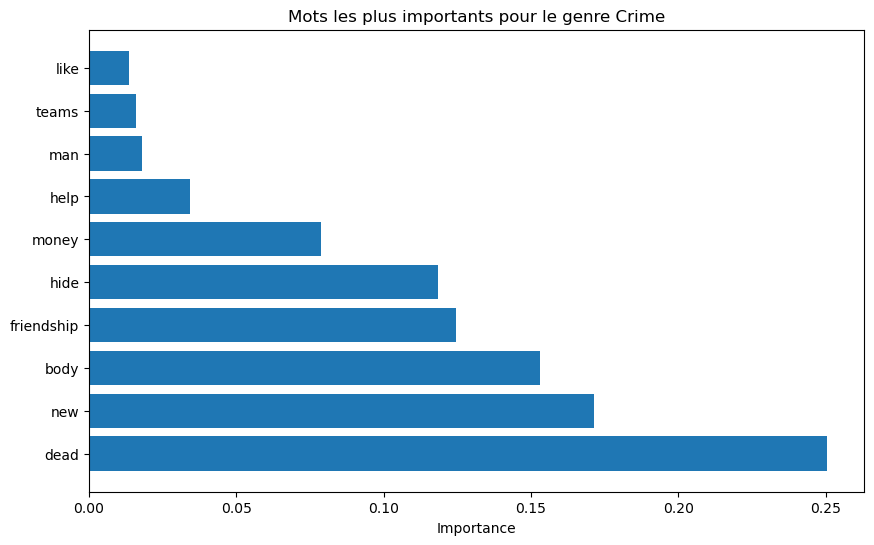

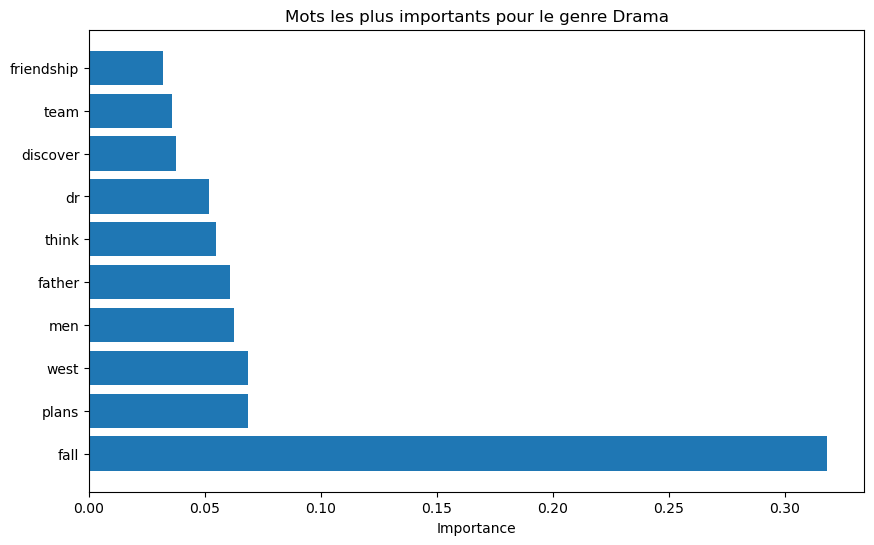

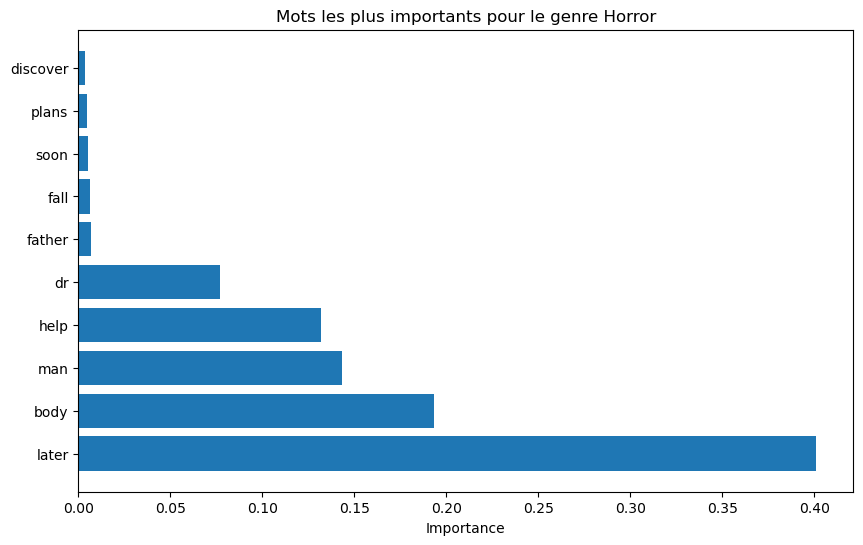

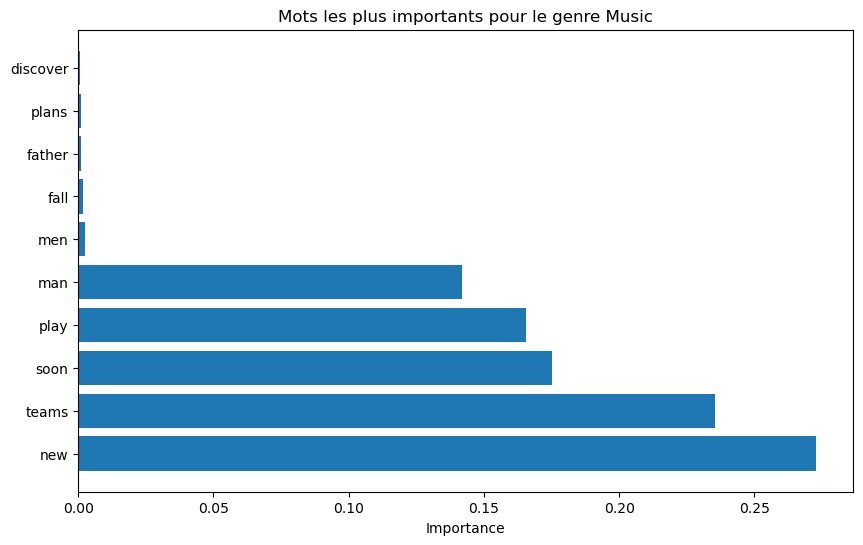

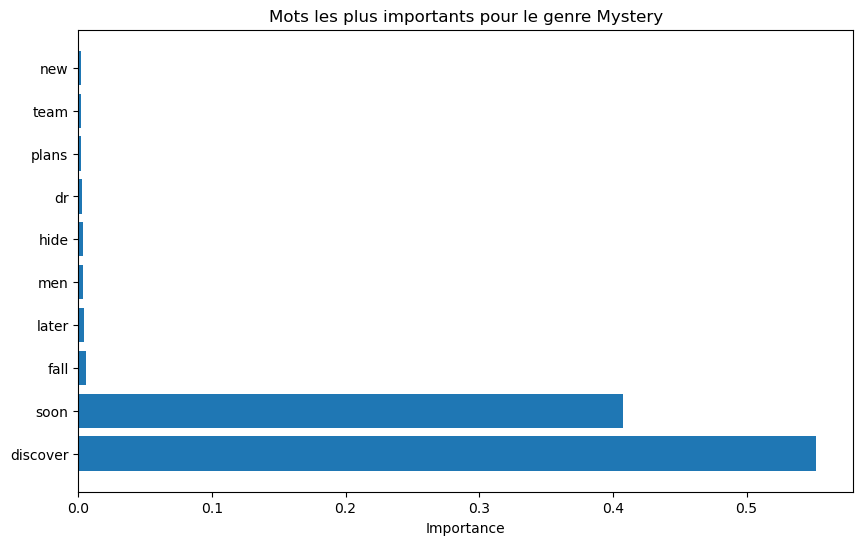

In [12]:


label_encoder = LabelEncoder()
df1['genre_encoded'] = label_encoder.fit_transform(df1['main_genre_name'])

# Séparer les données en caractéristiques (X) et labels (y)
X = df1['overview']
y = df1['genre_encoded']

# Diviser les données en un ensemble d'entraînement et un ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer le TfidfVectorizer avec des paramètres plus stricts
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, min_df=2, max_df=0.95)

# Appliquer le vectoriseur aux données d'entraînement
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Créer un modèle One-vs-Rest avec RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Appliquer One-vs-Rest pour chaque genre
ovr_model = OneVsRestClassifier(rf_model)
ovr_model.fit(X_train_tfidf, y_train)

# Vérifier la précision du modèle sur les données de test
accuracy = ovr_model.score(X_test_tfidf, y_test)
y_pred = ovr_model.predict(X_test_tfidf)

target_labels = label_encoder.classes_
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=target_labels, labels=np.arange(len(target_labels))))


print(f"Précision du modèle : {accuracy:.4f}")

# Optionnel : Visualiser les mots les plus importants pour un genre spécifique
def plot_important_words_for_genre(importances, feature_names, genre_index, top_n=10):
    sorted_indices = np.argsort(importances)[::-1][:top_n]
    words = [feature_names[i] for i in sorted_indices]
    scores = importances[sorted_indices]
    
    plt.figure(figsize=(10, 6))
    plt.barh(words, scores)
    plt.xlabel('Importance')
    plt.title(f'Mots les plus importants pour le genre {label_encoder.classes_[genre_index]}')
    plt.show()

for i in range(len(y.unique())):
    # Exemple : Visualiser les mots les plus importants pour le genre 0 (Drama)
    plot_important_words_for_genre(ovr_model.estimators_[i].feature_importances_, 
                                vectorizer.get_feature_names_out(), genre_index=i)

In [13]:
from sklearn.decomposition import PCA

dfrf=df1[df1['main_genre_id'].isin([18, 35])]

X=dfrf.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "revenue","budget","main_genre_id", "main_genre_id"])
y=dfrf['main_genre_id']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Convertir le résultat en DataFrame
X = pd.DataFrame(scaled_data, columns=X.columns)

print('Dimensions des données avant PCA : {}'.format(X.shape))

n_components = 2
pca = PCA(n_components=n_components)  # n_components entre 2 et le nombre de features (ici 5) 
x_2d = pca.fit_transform(X)
print('Dimensions des données après PCA : {}'.format(x_2d.shape))
print('components:\t{}'.format(pca.components_))
print('variance expliquée par les {} premières composantes:\t{}'.format(n_components, pca.explained_variance_ratio_))

# # ==> 99.9% de la variance associée au jeu de données est représenté par al 1ère composante 

# # Création d'un dataframe avec les données transformées:
columns=['Composante {}'.format(i) for i in range(1, n_components + 1)]
df_pca = pd.DataFrame(x_2d, columns=columns)
df_pca['classe'] = y


# # Visualiser les données PCA en 2D
plt.figure(figsize=(8, 6))
for classe in df_pca['classe'].unique():
    subset = df_pca[df_pca['classe'] == classe]
    plt.scatter(subset['Composante 1'], subset['Composante 2'], label=classe)

plt.title("Visualisation des données après PCA (2 dimensions)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend()
plt.show()
df_pca.head()

/opt/conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Dimensions des données avant PCA : (16, 10)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
df58=df1.drop("nwuri43d")
df58

KeyError: "['nwuri43d'] not found in axis"